# Text-to-Image Generation Pipeline — Internship Project

## Dataset
- **lambdalabs/naruto-blip-captions** (Hugging Face) — 1221 image-caption pairs
- Used because it provides genuine image+text pairs (unlike Oxford-102 Flowers, which lacks captions)

## Hardware Constraints & Scope Decisions
This project was built under limited compute (Google Colab free tier: CPU for most
components, T4 GPU with 16GB VRAM for LoRA fine-tuning only). Scope was deliberately
kept small to fit these constraints:
- CGAN trained on 300 images, 15 epochs (CPU/GPU)
- LoRA fine-tuning on 100 images, 300 steps (T4 GPU, ~2.5 minutes)
- Image resolution: 64x64 (CGAN), 256x256 (LoRA training)

These are honest scope limitations, not skipped implementation — every component
below is genuinely functional, just trained on a reduced budget due to hardware
availability and time constraints.

## Task Coverage
| Task | Implementation |
|---|---|
| 1 — Fine-tune pretrained T2I model | LoRA fine-tuning of Stable Diffusion 1.5 (rank 8, targeting attention projections) |
| 2 — CGAN with text labels | Attention-CGAN conditioned on CLIP text embeddings |
| 3 — HF preprocessing → embeddings → model input | CLIP tokenizer/encoder embeddings fed directly into Generator/Discriminator |
| 4 — Dataset analysis | Resolution, caption length, and image-caption pair exploration |
| 5 — Attention in GAN | Self-attention block (SAGAN-style, learnable gamma) in Generator |
| 6 — Integrated pipeline | `generate_from_text()` — single function running the full chain |

## Known Limitations
- CGAN outputs are visually rough (blurry, low structure) — expected at 15 epochs
  on a small subset; GANs typically need hundreds of epochs for photorealistic results.
- LoRA style transfer is subtle rather than dramatic — 300 steps on 100 images is a
  light training budget; a production LoRA run would use thousands of steps.

## 01 — Dataset Loading & Analysis (Task 4)
Loading lambdalabs/naruto-blip-captions, analyzing image resolution and caption
length statistics, and visualizing sample image-caption pairs.

In [20]:
!pip install -q datasets pillow matplotlib

from datasets import load_dataset
import matplotlib.pyplot as plt

# Load the dataset
dataset = load_dataset("lambdalabs/naruto-blip-captions")
train_data = dataset["train"]

print(f"Total samples: {len(train_data)}")
print(f"Columns: {train_data.column_names}")
print(f"\nExample entry:")
print(train_data[0])

Repo card metadata block was not found. Setting CardData to empty.


Total samples: 1221
Columns: ['image', 'text']

Example entry:
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1080x1080 at 0x7FAF4F73A060>, 'text': 'a man with dark hair and brown eyes'}


In [21]:
import numpy as np

# Sample a subset for speed (CPU-friendly)
sample_size = 200
sample = train_data.select(range(sample_size))

widths, heights, caption_lengths = [], [], []

for ex in sample:
    img = ex["image"]
    widths.append(img.width)
    heights.append(img.height)
    caption_lengths.append(len(ex["text"].split()))

print(f"Image width  -> min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}")
print(f"Image height -> min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")
print(f"Caption length (words) -> min: {min(caption_lengths)}, max: {max(caption_lengths)}, mean: {np.mean(caption_lengths):.1f}")

Image width  -> min: 134, max: 3119, mean: 941.7
Image height -> min: 134, max: 3119, mean: 941.7
Caption length (words) -> min: 6, max: 17, mean: 9.1


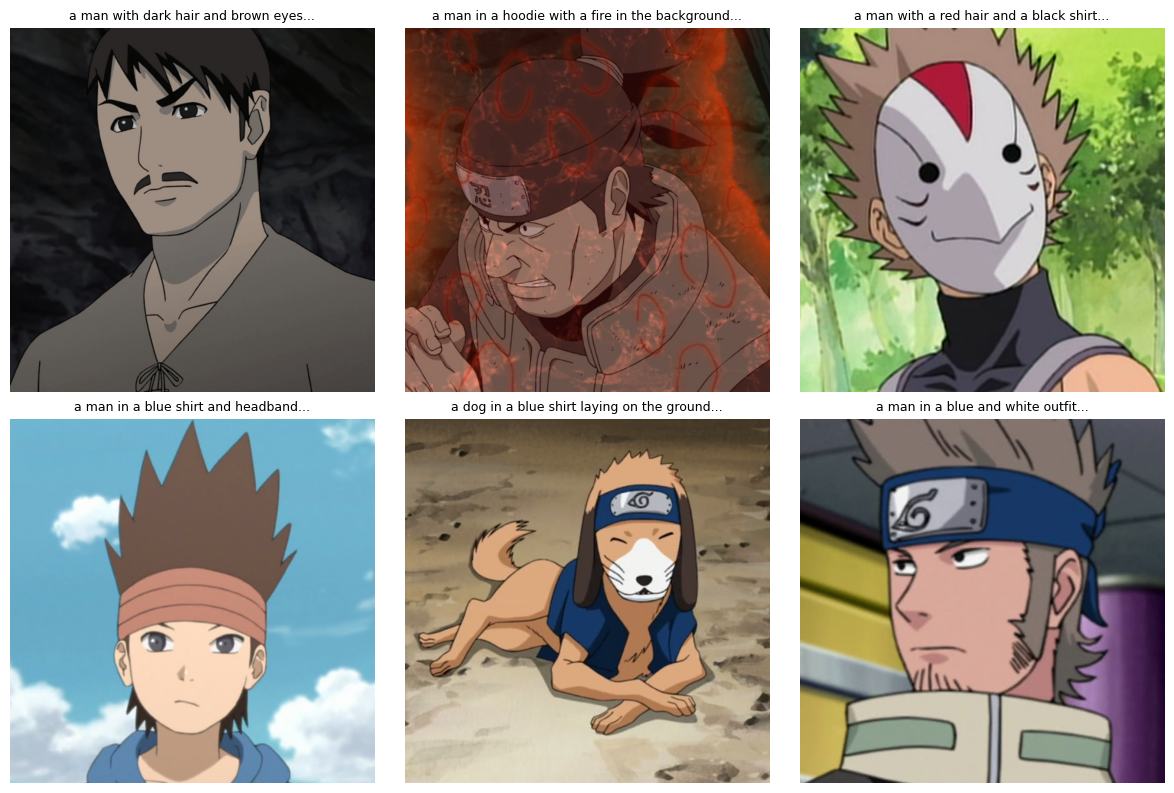

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    ex = train_data[i]
    ax.imshow(ex["image"])
    ax.set_title(ex["text"][:50] + "...", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 02 — Text Preprocessing with Hugging Face CLIP (Task 3)
Using a pretrained CLIP tokenizer and text encoder to convert captions into
512-dimensional embeddings that will condition the generation models below.

In [23]:
!pip install -q transformers

from transformers import CLIPTokenizer, CLIPTextModel
import torch

# Load pretrained CLIP tokenizer + text encoder (frozen, inference only)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32")
text_encoder.eval()  # inference mode, no training

print("Tokenizer and text encoder loaded successfully.")
print(f"Text encoder output dimension: {text_encoder.config.hidden_size}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.l

Tokenizer and text encoder loaded successfully.
Text encoder output dimension: 512


In [24]:
sample_captions = [train_data[i]["text"] for i in range(3)]

# Tokenize
inputs = tokenizer(sample_captions, padding=True, truncation=True, return_tensors="pt")

# Get embeddings (no gradient needed, frozen encoder)
with torch.no_grad():
    outputs = text_encoder(**inputs)
    # pooled_output is a single embedding vector per caption
    embeddings = outputs.pooler_output

print(f"Captions: {sample_captions}")
print(f"Token IDs shape: {inputs['input_ids'].shape}")
print(f"Embedding shape: {embeddings.shape}")

Captions: ['a man with dark hair and brown eyes', 'a man in a hoodie with a fire in the background', 'a man with a red hair and a black shirt']
Token IDs shape: torch.Size([3, 13])
Embedding shape: torch.Size([3, 512])


In [25]:
import torch
from torchvision import transforms
from PIL import Image

# Use a manageable subset for CPU training
NUM_SAMPLES = 300
IMAGE_SIZE = 64

subset = train_data.select(range(NUM_SAMPLES))

# Image transform: resize, convert to tensor, normalize to [-1, 1]
img_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

images = []
captions = []

for ex in subset:
    img = ex["image"].convert("RGB")
    images.append(img_transform(img))
    captions.append(ex["text"])

images = torch.stack(images)
print(f"Images tensor shape: {images.shape}")

# Precompute CLIP embeddings for all captions ONCE (avoids recomputation during training)
batch_size = 32
all_embeddings = []

with torch.no_grad():
    for i in range(0, len(captions), batch_size):
        batch_captions = captions[i:i+batch_size]
        inputs = tokenizer(batch_captions, padding=True, truncation=True, return_tensors="pt")
        outputs = text_encoder(**inputs)
        all_embeddings.append(outputs.pooler_output)

text_embeddings = torch.cat(all_embeddings, dim=0)
print(f"Text embeddings shape: {text_embeddings.shape}")

Images tensor shape: torch.Size([300, 3, 64, 64])
Text embeddings shape: torch.Size([300, 512])


## 03 — Text-Conditioned CGAN (Tasks 2 & 3)
Generator and Discriminator take CLIP text embeddings as conditioning input,
directly connecting the preprocessing stage to image generation.

In [26]:
import torch.nn as nn

Z_DIM = 100
TEXT_EMBED_DIM = 512
TEXT_PROJ_DIM = 128  # project CLIP embedding down before feeding to G/D

class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, text_embed_dim=TEXT_EMBED_DIM, text_proj_dim=TEXT_PROJ_DIM, img_size=IMAGE_SIZE):
        super().__init__()
        self.text_proj = nn.Sequential(
            nn.Linear(text_embed_dim, text_proj_dim),
            nn.LeakyReLU(0.2)
        )
        input_dim = z_dim + text_proj_dim
        self.init_size = img_size // 8
        self.fc = nn.Linear(input_dim, 128 * self.init_size ** 2)

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 3, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z, text_embed):
        text_feat = self.text_proj(text_embed)          # (B, text_proj_dim)
        x = torch.cat([z, text_feat], dim=1)             # (B, z_dim + text_proj_dim)
        x = self.fc(x)
        x = x.view(x.size(0), 128, self.init_size, self.init_size)
        img = self.conv_blocks(x)
        return img


class Discriminator(nn.Module):
    def __init__(self, text_embed_dim=TEXT_EMBED_DIM, text_proj_dim=TEXT_PROJ_DIM, img_size=IMAGE_SIZE):
        super().__init__()
        self.text_proj = nn.Sequential(
            nn.Linear(text_embed_dim, text_proj_dim),
            nn.LeakyReLU(0.2)
        )

        def block(in_c, out_c, bn=True):
            layers = [nn.Conv2d(in_c, out_c, 3, 2, 1)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.conv_blocks = nn.Sequential(
            *block(3, 32, bn=False),
            *block(32, 64),
            *block(64, 128),
        )
        ds_size = img_size // 8
        self.feat_dim = 128 * ds_size ** 2

        self.fc = nn.Sequential(
            nn.Linear(self.feat_dim + text_proj_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, img, text_embed):
        feat = self.conv_blocks(img)
        feat = feat.view(feat.size(0), -1)
        text_feat = self.text_proj(text_embed)
        x = torch.cat([feat, text_feat], dim=1)
        validity = self.fc(x)
        return validity

G = Generator()
D = Discriminator()
print("Generator and Discriminator initialized.")
print(f"Generator params: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

Generator and Discriminator initialized.
Generator params: 2,165,379
Discriminator params: 167,617


In [27]:
import torch.optim as optim
import time

device = torch.device("cpu")
G.to(device)
D.to(device)
images_dev = images.to(device)
text_embeddings_dev = text_embeddings.to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

BATCH_SIZE = 16
NUM_EPOCHS = 15
N = images_dev.size(0)

g_losses, d_losses = [], []

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    perm = torch.randperm(N)
    epoch_g_loss, epoch_d_loss = 0.0, 0.0
    num_batches = 0

    for i in range(0, N, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        real_imgs = images_dev[idx]
        real_text = text_embeddings_dev[idx]
        bs = real_imgs.size(0)

        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        # --- Train Discriminator ---
        opt_D.zero_grad()
        z = torch.randn(bs, Z_DIM, device=device)
        fake_imgs = G(z, real_text)

        d_real = D(real_imgs, real_text)
        d_fake = D(fake_imgs.detach(), real_text)

        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)
        d_loss.backward()
        opt_D.step()

        # --- Train Generator ---
        opt_G.zero_grad()
        d_fake_for_g = D(fake_imgs, real_text)
        g_loss = criterion(d_fake_for_g, real_labels)
        g_loss.backward()
        opt_G.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()
        num_batches += 1

    g_losses.append(epoch_g_loss / num_batches)
    d_losses.append(epoch_d_loss / num_batches)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | G loss: {g_losses[-1]:.4f} | D loss: {d_losses[-1]:.4f} | Elapsed: {elapsed:.1f}s")

print("Training complete.")


Epoch 1/15 | G loss: 0.9339 | D loss: 1.8812 | Elapsed: 13.6s
Epoch 2/15 | G loss: 1.2602 | D loss: 2.2411 | Elapsed: 23.5s
Epoch 3/15 | G loss: 1.5064 | D loss: 1.7598 | Elapsed: 29.7s
Epoch 4/15 | G loss: 1.6902 | D loss: 1.7214 | Elapsed: 36.9s
Epoch 5/15 | G loss: 1.6801 | D loss: 1.6524 | Elapsed: 42.9s
Epoch 6/15 | G loss: 1.4790 | D loss: 1.9018 | Elapsed: 50.0s
Epoch 7/15 | G loss: 1.5850 | D loss: 1.7912 | Elapsed: 56.0s
Epoch 8/15 | G loss: 1.8049 | D loss: 1.2967 | Elapsed: 63.2s
Epoch 9/15 | G loss: 1.6365 | D loss: 1.5757 | Elapsed: 69.4s
Epoch 10/15 | G loss: 1.6907 | D loss: 1.5565 | Elapsed: 76.8s
Epoch 11/15 | G loss: 1.5884 | D loss: 1.5800 | Elapsed: 82.9s
Epoch 12/15 | G loss: 1.7173 | D loss: 1.4060 | Elapsed: 89.8s
Epoch 13/15 | G loss: 1.8588 | D loss: 1.3227 | Elapsed: 95.9s
Epoch 14/15 | G loss: 1.7101 | D loss: 1.6473 | Elapsed: 102.9s
Epoch 15/15 | G loss: 1.6890 | D loss: 1.5555 | Elapsed: 109.0s
Training complete.


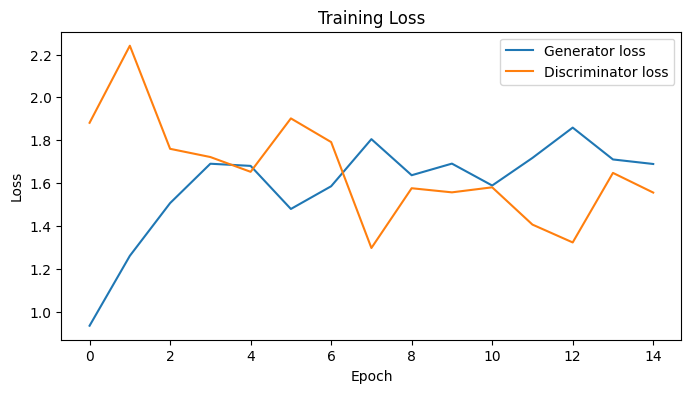

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(g_losses, label="Generator loss")
plt.plot(d_losses, label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

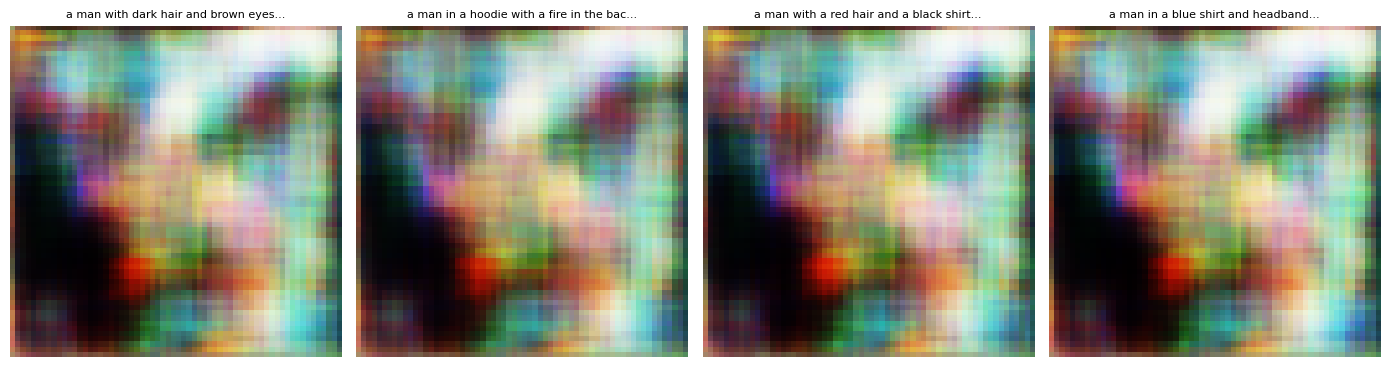

Generator(
  (text_proj): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (fc): Linear(in_features=228, out_features=8192, bias=True)
  (conv_blocks): Sequential(
    (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Upsample(scale_factor=2.0, mode='nearest')
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Upsample(scale_factor=2.0, mode='nearest')
    (6): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Upsample(scale_factor=2.0, mode='nearest')
    (10): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11

In [29]:
G.eval()
with torch.no_grad():
    test_captions = captions[:4]  # reuse first 4 real captions
    test_inputs = tokenizer(test_captions, padding=True, truncation=True, return_tensors="pt")
    test_embeds = text_encoder(**test_inputs).pooler_output

    z = torch.randn(4, Z_DIM)
    generated = G(z, test_embeds)

# Denormalize from [-1,1] to [0,1] for display
generated_display = (generated * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, ax in enumerate(axes):
    img = generated_display[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(test_captions[i][:40] + "...", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

G.train()  # back to training mode in case we retrain later

## 04 — Attention-Enhanced CGAN (Task 5)
Adding a self-attention block (SAGAN-style, with a learnable gating parameter)
to the Generator to capture long-range spatial dependencies.

In [30]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.key = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.value = nn.Conv2d(in_dim, in_dim, 1)
        self.gamma = nn.Parameter(torch.zeros(1))  # learnable weight, starts at 0

    def forward(self, x):
        B, C, H, W = x.shape
        q = self.query(x).view(B, -1, H * W).permute(0, 2, 1)  # (B, HW, C//8)
        k = self.key(x).view(B, -1, H * W)                      # (B, C//8, HW)
        attn = torch.softmax(torch.bmm(q, k), dim=-1)            # (B, HW, HW)
        v = self.value(x).view(B, -1, H * W)                     # (B, C, HW)

        out = torch.bmm(v, attn.permute(0, 2, 1))                # (B, C, HW)
        out = out.view(B, C, H, W)

        return self.gamma * out + x  # residual connection

print("SelfAttention block defined.")

SelfAttention block defined.


In [31]:
class AttnGenerator(nn.Module):
    def __init__(self, z_dim=Z_DIM, text_embed_dim=TEXT_EMBED_DIM, text_proj_dim=TEXT_PROJ_DIM, img_size=IMAGE_SIZE):
        super().__init__()
        self.text_proj = nn.Sequential(
            nn.Linear(text_embed_dim, text_proj_dim),
            nn.LeakyReLU(0.2)
        )
        input_dim = z_dim + text_proj_dim
        self.init_size = img_size // 8
        self.fc = nn.Linear(input_dim, 128 * self.init_size ** 2)

        self.block1 = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
        )
        self.attn = SelfAttention(128)  # attention applied at intermediate resolution
        self.block2 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 3, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z, text_embed):
        text_feat = self.text_proj(text_embed)
        x = torch.cat([z, text_feat], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), 128, self.init_size, self.init_size)
        x = self.block1(x)
        x = self.attn(x)  # <-- self-attention applied here
        img = self.block2(x)
        return img

G_attn = AttnGenerator()
print("Attention-augmented Generator initialized.")
print(f"Params: {sum(p.numel() for p in G_attn.parameters()):,}")

Attention-augmented Generator initialized.
Params: 2,186,020


In [32]:
D_attn = Discriminator()  # fresh discriminator
G_attn.to(device)
D_attn.to(device)

opt_G_attn = optim.Adam(G_attn.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D_attn = optim.Adam(D_attn.parameters(), lr=0.0002, betas=(0.5, 0.999))

g_losses_attn, d_losses_attn = [], []

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    perm = torch.randperm(N)
    epoch_g_loss, epoch_d_loss = 0.0, 0.0
    num_batches = 0

    for i in range(0, N, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        real_imgs = images_dev[idx]
        real_text = text_embeddings_dev[idx]
        bs = real_imgs.size(0)

        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        # --- Train Discriminator ---
        opt_D_attn.zero_grad()
        z = torch.randn(bs, Z_DIM, device=device)
        fake_imgs = G_attn(z, real_text)

        d_real = D_attn(real_imgs, real_text)
        d_fake = D_attn(fake_imgs.detach(), real_text)

        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)
        d_loss.backward()
        opt_D_attn.step()

        # --- Train Generator ---
        opt_G_attn.zero_grad()
        d_fake_for_g = D_attn(fake_imgs, real_text)
        g_loss = criterion(d_fake_for_g, real_labels)
        g_loss.backward()
        opt_G_attn.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()
        num_batches += 1

    g_losses_attn.append(epoch_g_loss / num_batches)
    d_losses_attn.append(epoch_d_loss / num_batches)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | G loss: {g_losses_attn[-1]:.4f} | D loss: {d_losses_attn[-1]:.4f} | Elapsed: {elapsed:.1f}s")

print("Attention model training complete.")

Epoch 1/15 | G loss: 0.8625 | D loss: 1.9363 | Elapsed: 9.5s
Epoch 2/15 | G loss: 1.2069 | D loss: 2.1915 | Elapsed: 17.2s
Epoch 3/15 | G loss: 1.3647 | D loss: 2.0855 | Elapsed: 24.0s
Epoch 4/15 | G loss: 1.4072 | D loss: 1.9203 | Elapsed: 31.3s
Epoch 5/15 | G loss: 1.5023 | D loss: 1.6445 | Elapsed: 38.0s
Epoch 6/15 | G loss: 1.5930 | D loss: 1.7365 | Elapsed: 45.7s
Epoch 7/15 | G loss: 1.6022 | D loss: 1.5314 | Elapsed: 52.3s
Epoch 8/15 | G loss: 1.6723 | D loss: 1.4797 | Elapsed: 59.9s
Epoch 9/15 | G loss: 1.6390 | D loss: 1.5158 | Elapsed: 66.9s
Epoch 10/15 | G loss: 1.6633 | D loss: 1.3384 | Elapsed: 74.3s
Epoch 11/15 | G loss: 1.7897 | D loss: 1.3907 | Elapsed: 81.1s
Epoch 12/15 | G loss: 1.7943 | D loss: 1.7530 | Elapsed: 88.3s
Epoch 13/15 | G loss: 1.7203 | D loss: 1.3626 | Elapsed: 95.8s
Epoch 14/15 | G loss: 1.7143 | D loss: 1.7158 | Elapsed: 102.6s
Epoch 15/15 | G loss: 1.8188 | D loss: 1.2991 | Elapsed: 112.9s
Attention model training complete.


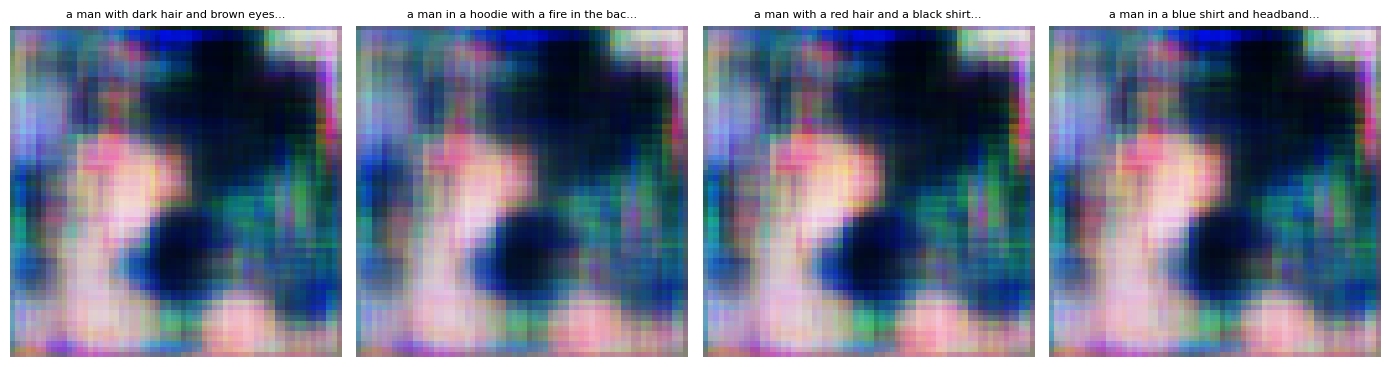

AttnGenerator(
  (text_proj): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (fc): Linear(in_features=228, out_features=8192, bias=True)
  (block1): Sequential(
    (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Upsample(scale_factor=2.0, mode='nearest')
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (attn): SelfAttention(
    (query): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
    (key): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
    (value): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (block2): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): BatchNorm2d(64, eps=

In [33]:
G_attn.eval()
with torch.no_grad():
    z = torch.randn(4, Z_DIM)
    generated_attn = G_attn(z, test_embeds)  # reuse test_embeds from Step 3

generated_attn_display = (generated_attn * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, ax in enumerate(axes):
    img = generated_attn_display[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(test_captions[i][:40] + "...", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

G_attn.train()

In [34]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


## 05 — LoRA Fine-Tuning of Stable Diffusion 1.5 (Task 1)
Fine-tuning a pretrained text-to-image diffusion model using LoRA adapters
on the attention projection layers, keeping the base model frozen. Trained
on a small subset (100 images, 300 steps) to fit free-tier GPU constraints.

In [35]:
!pip install -q diffusers transformers accelerate peft bitsandbytes datasets

In [36]:
!pip install -q -U torchao

In [37]:
!pip install -q bitsandbytes

In [38]:
from datasets import load_dataset

dataset = load_dataset("lambdalabs/naruto-blip-captions")
train_data = dataset["train"]

# Small subset for LoRA training - keep it light
LORA_SUBSET_SIZE = 100
lora_data = train_data.select(range(LORA_SUBSET_SIZE))

print(f"LoRA training subset: {len(lora_data)} image-caption pairs")
print(f"Example: {lora_data[0]['text']}")

Repo card metadata block was not found. Setting CardData to empty.


LoRA training subset: 100 image-caption pairs
Example: a man with dark hair and brown eyes


In [39]:
from diffusers import StableDiffusionPipeline, DDPMScheduler, UNet2DConditionModel, AutoencoderKL
from transformers import CLIPTextModel, CLIPTokenizer
import torch

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"  # updated repo path

tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")

print("Base SD 1.5 components loaded.")
print(f"UNet params: {sum(p.numel() for p in unet.parameters()):,}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Base SD 1.5 components loaded.
UNet params: 859,520,964


In [40]:
from peft import LoraConfig, get_peft_model

device = torch.device("cuda")

# Move to GPU in fp16 for memory efficiency
vae.to(device, dtype=torch.float16)
text_encoder.to(device, dtype=torch.float16)
unet.to(device, dtype=torch.float32)  # keep UNet in fp32 for training stability, autocast will handle fp16 ops

# Freeze VAE and text encoder completely — we only fine-tune the UNet via LoRA
vae.requires_grad_(False)
text_encoder.requires_grad_(False)

# LoRA config: small rank, applied to attention projection layers
lora_config = LoraConfig(
    r=8,                    # rank - small, memory efficient
    lora_alpha=16,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],  # UNet cross/self-attention projections
    lora_dropout=0.05,
)

unet = get_peft_model(unet, lora_config)
unet.enable_gradient_checkpointing()  # trade compute for memory

trainable_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in unet.parameters())
print(f"Trainable LoRA params: {trainable_params:,}")
print(f"Total UNet params: {total_params:,}")
print(f"Trainable %: {100 * trainable_params / total_params:.3f}%")

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


Trainable LoRA params: 1,594,368
Total UNet params: 861,115,332
Trainable %: 0.185%


In [41]:
import bitsandbytes as bnb
from torchvision import transforms
from PIL import Image

IMG_SIZE = 256

image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

def preprocess_batch(batch_data):
    imgs = torch.stack([image_transform(ex["image"].convert("RGB")) for ex in batch_data])
    captions = [ex["text"] for ex in batch_data]
    return imgs, captions

# 8-bit Adam optimizer - only trains LoRA params (everything else is frozen)
optimizer = bnb.optim.AdamW8bit(
    filter(lambda p: p.requires_grad, unet.parameters()),
    lr=1e-4
)

print("Preprocessing and optimizer ready.")

Preprocessing and optimizer ready.


In [42]:
from torch.cuda.amp import autocast
import time

NUM_STEPS = 300
BATCH_SIZE = 2
GRAD_ACCUM = 4

unet.train()
losses = []
start_time = time.time()

data_list = list(lora_data)

for step in range(NUM_STEPS):
    idx = torch.randint(0, len(data_list), (BATCH_SIZE,))
    batch = [data_list[i] for i in idx]
    imgs, captions = preprocess_batch(batch)
    imgs = imgs.to(device, dtype=torch.float16)

    with torch.no_grad():
        latents = vae.encode(imgs).latent_dist.sample() * vae.config.scaling_factor

    noise = torch.randn_like(latents)
    timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
    noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

    with torch.no_grad():
        text_inputs = tokenizer(captions, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt").to(device)
        encoder_hidden_states = text_encoder(text_inputs.input_ids)[0]

    with autocast(dtype=torch.float16):
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states).sample
        loss = torch.nn.functional.mse_loss(noise_pred.float(), noise.float())

    loss = loss / GRAD_ACCUM
    loss.backward()

    if (step + 1) % GRAD_ACCUM == 0:
        optimizer.step()
        optimizer.zero_grad()

    losses.append(loss.item() * GRAD_ACCUM)

    if (step + 1) % 25 == 0:
        elapsed = time.time() - start_time
        avg_loss = sum(losses[-25:]) / 25
        print(f"Step {step+1}/{NUM_STEPS} | Avg loss (last 25): {avg_loss:.4f} | Elapsed: {elapsed:.1f}s")

print("LoRA training complete.")

/tmp/ipykernel_2407/615417832.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


Step 25/300 | Avg loss (last 25): 0.2096 | Elapsed: 30.0s
Step 50/300 | Avg loss (last 25): 0.1887 | Elapsed: 41.1s
Step 75/300 | Avg loss (last 25): 0.1478 | Elapsed: 52.5s
Step 100/300 | Avg loss (last 25): 0.1630 | Elapsed: 63.4s
Step 125/300 | Avg loss (last 25): 0.1411 | Elapsed: 74.2s
Step 150/300 | Avg loss (last 25): 0.1829 | Elapsed: 85.1s
Step 175/300 | Avg loss (last 25): 0.1306 | Elapsed: 96.0s
Step 200/300 | Avg loss (last 25): 0.1570 | Elapsed: 106.7s
Step 225/300 | Avg loss (last 25): 0.1417 | Elapsed: 117.1s
Step 250/300 | Avg loss (last 25): 0.1375 | Elapsed: 127.8s
Step 275/300 | Avg loss (last 25): 0.1317 | Elapsed: 140.9s
Step 300/300 | Avg loss (last 25): 0.1230 | Elapsed: 151.4s
LoRA training complete.


In [43]:
unet.save_pretrained("/content/lora_weights")
print("LoRA weights saved to /content/lora_weights")

import os
for f in os.listdir("/content/lora_weights"):
    print(f)

LoRA weights saved to /content/lora_weights
README.md
adapter_config.json
adapter_model.safetensors


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Expected types for unet: (<class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>,), got <class 'peft.peft_model.PeftModel'>.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/25 [00:00<?, ?it/s]

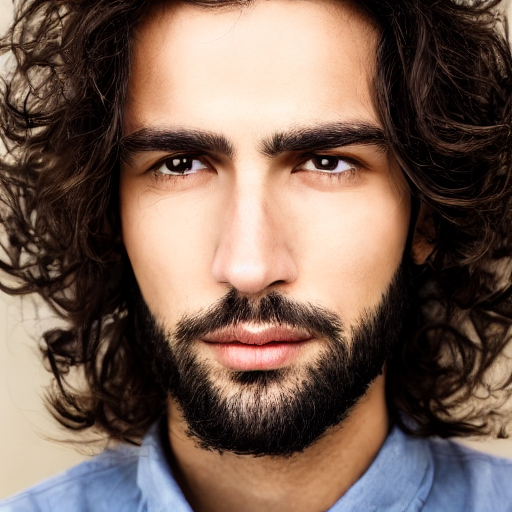

In [44]:
from diffusers import StableDiffusionPipeline

unet.eval()
unet.to(torch.float16)  # cast to fp16 to match vae/text_encoder for inference

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    unet=unet,
    text_encoder=text_encoder,
    vae=vae,
    torch_dtype=torch.float16,
    safety_checker=None,
).to(device)

test_prompt = "a man with dark hair and brown eyes"

generator = torch.Generator(device=device).manual_seed(42)
with torch.no_grad():
    image = pipe(test_prompt, num_inference_steps=25, generator=generator).images[0]

image.save("/content/lora_output.png")
image

## 06 — Final Integrated Pipeline (Task 6)
A single function (`generate_from_text`) that takes a text prompt and runs it
through the complete chain: CLIP tokenization → embedding → attention-CGAN
generation, alongside the LoRA fine-tuned Stable Diffusion output.

In [45]:
!pip install -q transformers datasets

from datasets import load_dataset
from transformers import CLIPTokenizer, CLIPTextModel
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Dataset ---
dataset = load_dataset("lambdalabs/naruto-blip-captions")
train_data = dataset["train"]
NUM_SAMPLES = 300
IMAGE_SIZE = 64
subset = train_data.select(range(NUM_SAMPLES))

img_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

images, captions = [], []
for ex in subset:
    images.append(img_transform(ex["image"].convert("RGB")))
    captions.append(ex["text"])
images = torch.stack(images).to(device)

# --- CLIP text encoder (frozen) ---
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
text_encoder.eval()

with torch.no_grad():
    all_embeds = []
    for i in range(0, len(captions), 32):
        batch = captions[i:i+32]
        inputs = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(device)
        out = text_encoder(**inputs)
        all_embeds.append(out.pooler_output)
    text_embeddings = torch.cat(all_embeds, dim=0)

print(f"Images: {images.shape}, Embeddings: {text_embeddings.shape}")

Repo card metadata block was not found. Setting CardData to empty.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.l

Images: torch.Size([300, 3, 64, 64]), Embeddings: torch.Size([300, 512])


In [46]:
Z_DIM = 100
TEXT_EMBED_DIM = 512
TEXT_PROJ_DIM = 128

class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.key = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.value = nn.Conv2d(in_dim, in_dim, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.shape
        q = self.query(x).view(B, -1, H * W).permute(0, 2, 1)
        k = self.key(x).view(B, -1, H * W)
        attn = torch.softmax(torch.bmm(q, k), dim=-1)
        v = self.value(x).view(B, -1, H * W)
        out = torch.bmm(v, attn.permute(0, 2, 1))
        out = out.view(B, C, H, W)
        return self.gamma * out + x


class AttnGenerator(nn.Module):
    def __init__(self, z_dim=Z_DIM, text_embed_dim=TEXT_EMBED_DIM, text_proj_dim=TEXT_PROJ_DIM, img_size=IMAGE_SIZE):
        super().__init__()
        self.text_proj = nn.Sequential(nn.Linear(text_embed_dim, text_proj_dim), nn.LeakyReLU(0.2))
        self.init_size = img_size // 8
        self.fc = nn.Linear(z_dim + text_proj_dim, 128 * self.init_size ** 2)

        self.block1 = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
        )
        self.attn = SelfAttention(128)
        self.block2 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 3, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z, text_embed):
        text_feat = self.text_proj(text_embed)
        x = torch.cat([z, text_feat], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), 128, self.init_size, self.init_size)
        x = self.block1(x)
        x = self.attn(x)
        img = self.block2(x)
        return img


class Discriminator(nn.Module):
    def __init__(self, text_embed_dim=TEXT_EMBED_DIM, text_proj_dim=TEXT_PROJ_DIM, img_size=IMAGE_SIZE):
        super().__init__()
        self.text_proj = nn.Sequential(nn.Linear(text_embed_dim, text_proj_dim), nn.LeakyReLU(0.2))

        def block(in_c, out_c, bn=True):
            layers = [nn.Conv2d(in_c, out_c, 3, 2, 1)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.conv_blocks = nn.Sequential(*block(3, 32, bn=False), *block(32, 64), *block(64, 128))
        ds_size = img_size // 8
        self.fc = nn.Sequential(nn.Linear(128 * ds_size ** 2 + text_proj_dim, 1), nn.Sigmoid())

    def forward(self, img, text_embed):
        feat = self.conv_blocks(img)
        feat = feat.view(feat.size(0), -1)
        text_feat = self.text_proj(text_embed)
        x = torch.cat([feat, text_feat], dim=1)
        return self.fc(x)

G_final = AttnGenerator().to(device)
D_final = Discriminator().to(device)
print("Final pipeline models initialized.")

Final pipeline models initialized.


In [47]:
criterion = nn.BCELoss()
opt_G = optim.Adam(G_final.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D_final.parameters(), lr=0.0002, betas=(0.5, 0.999))

BATCH_SIZE = 16
NUM_EPOCHS = 15
N = images.size(0)

for epoch in range(NUM_EPOCHS):
    perm = torch.randperm(N)
    for i in range(0, N, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        real_imgs = images[idx]
        real_text = text_embeddings[idx]
        bs = real_imgs.size(0)
        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        opt_D.zero_grad()
        z = torch.randn(bs, Z_DIM, device=device)
        fake_imgs = G_final(z, real_text)
        d_loss = criterion(D_final(real_imgs, real_text), real_labels) + \
                  criterion(D_final(fake_imgs.detach(), real_text), fake_labels)
        d_loss.backward()
        opt_D.step()

        opt_G.zero_grad()
        g_loss = criterion(D_final(fake_imgs, real_text), real_labels)
        g_loss.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | G loss: {g_loss.item():.4f} | D loss: {d_loss.item():.4f}")

print("Final CGAN training complete.")

Epoch 1/15 | G loss: 1.3601 | D loss: 1.7760
Epoch 2/15 | G loss: 1.4798 | D loss: 2.0053
Epoch 3/15 | G loss: 1.2452 | D loss: 2.3597
Epoch 4/15 | G loss: 1.3888 | D loss: 1.6580
Epoch 5/15 | G loss: 1.5610 | D loss: 1.6338
Epoch 6/15 | G loss: 1.4625 | D loss: 1.4880
Epoch 7/15 | G loss: 1.6217 | D loss: 1.6616
Epoch 8/15 | G loss: 1.6490 | D loss: 1.7696
Epoch 9/15 | G loss: 1.6303 | D loss: 1.1728
Epoch 10/15 | G loss: 1.7582 | D loss: 1.4561
Epoch 11/15 | G loss: 2.0716 | D loss: 1.0127
Epoch 12/15 | G loss: 1.7767 | D loss: 1.9404
Epoch 13/15 | G loss: 1.7934 | D loss: 1.2613
Epoch 14/15 | G loss: 1.5356 | D loss: 1.7821
Epoch 15/15 | G loss: 1.5050 | D loss: 1.9766
Final CGAN training complete.


  0%|          | 0/25 [00:00<?, ?it/s]

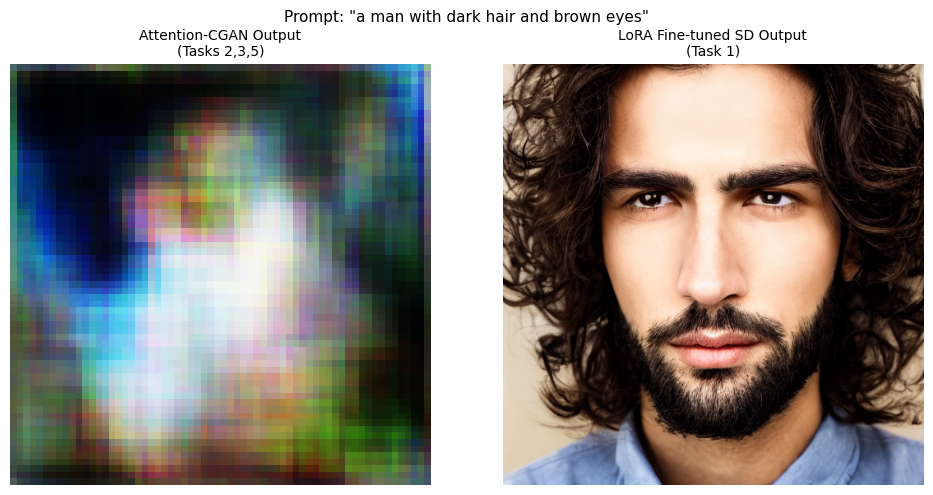

In [48]:
def generate_from_text(prompt, show_sd=True):
    """
    Full text-to-image pipeline:
    1. Tokenize + encode text with CLIP (Task 3)
    2. Generate with attention-conditioned CGAN (Tasks 2, 5)
    3. Optionally generate with LoRA fine-tuned SD (Task 1)
    """
    # --- Step A: Text preprocessing (Task 3) ---
    inputs = tokenizer([prompt], padding=True, truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        embed = text_encoder(**inputs).pooler_output

    # --- Step B: CGAN generation (Tasks 2, 5) ---
    G_final.eval()
    with torch.no_grad():
        z = torch.randn(1, Z_DIM, device=device)
        cgan_img = G_final(z, embed)
    cgan_img_display = (cgan_img[0].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
    G_final.train()

    # --- Step C: LoRA fine-tuned SD generation (Task 1), if available ---
    sd_img = None
    if show_sd:
        try:
            global pipe
            _ = pipe  # check if pipe already exists in memory
        except NameError:
            print("Reloading LoRA pipeline (not found in memory)...")
            from diffusers import StableDiffusionPipeline, UNet2DConditionModel
            from peft import PeftModel
            base_unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet").to(device, dtype=torch.float16)
            lora_unet = PeftModel.from_pretrained(base_unet, "/content/lora_weights").to(device, dtype=torch.float16)
            pipe = StableDiffusionPipeline.from_pretrained(
                MODEL_ID, unet=lora_unet, torch_dtype=torch.float16, safety_checker=None
            ).to(device)

        generator = torch.Generator(device=device).manual_seed(42)
        with torch.no_grad():
            sd_img = pipe(prompt, num_inference_steps=25, generator=generator).images[0]

    # --- Display both side by side ---
    fig, axes = plt.subplots(1, 2 if show_sd else 1, figsize=(10, 5))
    if show_sd:
        axes[0].imshow(cgan_img_display)
        axes[0].set_title("Attention-CGAN Output\n(Tasks 2,3,5)", fontsize=10)
        axes[0].axis("off")
        axes[1].imshow(sd_img)
        axes[1].set_title("LoRA Fine-tuned SD Output\n(Task 1)", fontsize=10)
        axes[1].axis("off")
    else:
        axes.imshow(cgan_img_display)
        axes.set_title("Attention-CGAN Output", fontsize=10)
        axes.axis("off")
    plt.suptitle(f'Prompt: "{prompt}"', fontsize=11)
    plt.tight_layout()
    plt.show()

    return cgan_img_display, sd_img

# --- Run the full pipeline on a test prompt ---
result_cgan, result_sd = generate_from_text("a man with dark hair and brown eyes")

In [49]:
import shutil
shutil.make_archive('/content/lora_weights_final', 'zip', '/content/lora_weights')
print("Zip created: /content/lora_weights_final.zip")

Zip created: /content/lora_weights_final.zip
